# DXF → Density Map → SAM Segmentation

**Pipeline:**
```
DXF
 ↓
① Render overview (2048px)
 ↓
② Morphological opening  →  kill thin pipes/connectors
 ↓
③ Multi-scale density map  →  dense regions = objects
 ↓
④ Threshold + Watershed  →  object candidate bboxes
 ↓
⑤ Area filter  →  discard noise + overviews
 ↓
⑥ SAM with BOX PROMPTS (not point grid)  →  precise masks
 ↓
⑦ Render each mask bbox from DXF at hi-res  →  save
```

Key difference from previous approach: SAM receives **guided box prompts**
from density regions — not a random point grid. No recursion. No infinite loops.

Run cells top to bottom.

In [ ]:
# ── Install ───────────────────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install -q \
    ezdxf cairosvg matplotlib numpy Pillow \
    opencv-python-headless scipy \
    segment-anything torch torchvision
print('packages ready')

packages ready


In [ ]:
# ── Download SAM checkpoint ───────────────────────────────────────────────
import os, urllib.request

CHECKPOINTS = {
    'vit_h': ('sam_vit_h_4b8939.pth',
              'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'),
    'vit_b': ('sam_vit_b_01ec64.pth',
              'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'),
}
DOWNLOAD_MODEL = 'vit_h'
fname, url = CHECKPOINTS[DOWNLOAD_MODEL]

if os.path.exists(fname):
    print(f'checkpoint present: {fname}  ({os.path.getsize(fname)/1e9:.2f} GB)')
else:
    print(f'Downloading {fname} ...')
    def _prog(c,b,t): print(f'  {min(c*b/t,1)*100:5.1f}%', end='\r')
    urllib.request.urlretrieve(url, fname, reporthook=_prog)
    print(f'\ndone  ({os.path.getsize(fname)/1e9:.2f} GB)')

checkpoint present: sam_vit_h_4b8939.pth  (2.56 GB)


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────
import gc, io, math, json, warnings
from pathlib import Path
from PIL import Image

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from segment_anything import sam_model_registry, SamPredictor

import cairosvg
import ezdxf

warnings.filterwarnings('ignore')
Image.MAX_IMAGE_PIXELS = None

# ── Environment detection ─────────────────────────────────────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'imports OK  |  Colab={IN_COLAB}')

imports OK  |  Colab=True


## Configuration

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# ── Input / Output paths ──────────────────────────────────────────────────
# Set UPLOAD_DXF = True to upload via Colab dialog; False uses DXF_PATH directly
UPLOAD_DXF = True

if IN_COLAB and UPLOAD_DXF:
    from google.colab import files
    print('Upload your .dxf file:')
    uploaded = files.upload()
    DXF_PATH = list(uploaded.keys())[0]
    print(f'  Using uploaded: {DXF_PATH}')
else:
    DXF_PATH = 'HY2M - Leap.dxf'  # local path — change as needed

OUTPUT_DIR = '.'

# ── Overview render ───────────────────────────────────────────────────────
OVERVIEW_PX = 2048        # low-res overview for density analysis

# ── Hi-res tile render ────────────────────────────────────────────────────
TILE_LONG_EDGE_PX = 8192  # final output resolution per segment

# ── Density map settings ──────────────────────────────────────────────────
# Morphological opening kernel — kills connections thinner than this (px).
# Keep small (1-2) to preserve thin lines that define object boundaries.
OPEN_KERNEL_PX = 1

# Gaussian blur sigmas for multi-scale density.
# Larger sigmas spread density further → whole objects captured, not just dense spots.
DENSITY_SIGMAS = [15, 40, 80]

# Density threshold [0-1] — lower = more area included per region.
DENSITY_THRESHOLD = 0.06

# ── Region filters ────────────────────────────────────────────────────────
# Min region area as fraction of overview — smaller = noise, discard
MIN_REGION_FRACTION = 0.005   # 0.5% of overview

# Max region area as fraction of overview — larger = overview/panel, keep
# but flag as 'large' for orchestrator, skip fine SAM
MAX_REGION_FRACTION = 0.40    # 40% of overview

# ── SAM settings ──────────────────────────────────────────────────────────
SAM_CHECKPOINT  = fname        # from download cell
SAM_MODEL_TYPE  = DOWNLOAD_MODEL
SAM_INPUT_PX    = 1024         # SAM always gets images at this size

# Box prompt padding: expand each density bbox by this fraction before SAM
# 0.05 = 5% (tight crop), 0.20 = 20% (comfortable margin around segment)
BOX_PAD_FRACTION = 0.20
# ══════════════════════════════════════════════════════════════════════════

TILES_DIR    = os.path.join(OUTPUT_DIR, 'density_tiles')
SEGMENTS_DIR = os.path.join(OUTPUT_DIR, 'density_segments')
for d in [TILES_DIR, SEGMENTS_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')
print(f'DXF   : {DXF_PATH}')

Upload your .dxf file:


Saving HY2M - Leap mini.dwg (1).dxf to HY2M - Leap mini.dwg (1) (2).dxf
  Using uploaded: HY2M - Leap mini.dwg (1) (2).dxf
Output: .
DXF   : HY2M - Leap mini.dwg (1) (2).dxf


## ① SVG Renderer

In [ ]:
# ── DXF → SVG → PNG renderer ──────────────────────────────────────────────
ACI = {
    1:'#DD0000',2:'#BBBB00',3:'#009900',4:'#009999',
    5:'#0000DD',6:'#990099',7:'#000000',
    8:'#333333',9:'#666666',
    30:'#FF8000',50:'#CCCC00',90:'#00AAAA',
    250:'#222222',251:'#444444',252:'#555555',
    253:'#777777',254:'#AAAAAA',255:'#CCCCCC',
}

def _color(ent, doc):
    try:
        idx = ent.dxf.color
        if idx == 256:
            layer = doc.layers.get(ent.dxf.layer)
            idx = layer.dxf.color if (layer and layer.dxf.hasattr('color')) else 7
        return '#000000' if idx in (0,7) else ACI.get(idx,'#111111')
    except Exception:
        return '#111111'

def _arc_d(cx,cy,r,a1d,a2d):
    a1,a2 = math.radians(a1d),math.radians(a2d)
    if a2<=a1: a2+=2*math.pi
    span=a2-a1
    if span>=2*math.pi-1e-6:
        return f'M {cx+r:.4f} {cy:.4f} A {r:.4f} {r:.4f} 0 1 0 {cx-r:.4f} {cy:.4f} A {r:.4f} {r:.4f} 0 1 0 {cx+r:.4f} {cy:.4f} Z'
    x1=cx+r*math.cos(a1);y1=cy+r*math.sin(a1)
    x2=cx+r*math.cos(a2);y2=cy+r*math.sin(a2)
    return f'M {x1:.4f} {y1:.4f} A {r:.4f} {r:.4f} 0 {1 if span>math.pi else 0} 1 {x2:.4f} {y2:.4f}'

def _poly_d(pts,close=False):
    d=f'M {pts[0][0]:.4f} {pts[0][1]:.4f}'+''.join(f' L {p[0]:.4f} {p[1]:.4f}' for p in pts[1:])
    return d+(' Z' if close else '')

def render_region(doc, xmn,ymn,xmx,ymx, long_edge_px, out_png=None):
    W,H = xmx-xmn,ymx-ymn
    sw  = max(max(W,H)/long_edge_px, max(W,H)/50000)
    lines=[
        f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="{xmn:.4f} {-ymx:.4f} {W:.4f} {H:.4f}" width="{W:.4f}" height="{H:.4f}">',
        f'<rect x="{xmn:.4f}" y="{-ymx:.4f}" width="{W:.4f}" height="{H:.4f}" fill="white"/>',
        '<g transform="scale(1,-1)">',
    ]
    def emit(ent):
        col=_color(ent,doc); et=ent.dxftype()
        st=f'stroke:{col};stroke-width:{sw:.6f};fill:none;stroke-linecap:round;stroke-linejoin:round'
        try:
            if et=='LINE':
                s,e=ent.dxf.start,ent.dxf.end
                lines.append(f'<line x1="{s.x:.4f}" y1="{s.y:.4f}" x2="{e.x:.4f}" y2="{e.y:.4f}" style="{st}"/>')
            elif et in ('LWPOLYLINE','POLYLINE'):
                pts=([(p[0],p[1]) for p in ent.get_points()] if et=='LWPOLYLINE'
                     else [(v.dxf.location.x,v.dxf.location.y) for v in ent.vertices])
                if len(pts)<2: return
                lines.append(f'<path d="{_poly_d(pts,getattr(ent,"is_closed",False))}" style="{st}"/>')
            elif et=='CIRCLE':
                c,r=ent.dxf.center,ent.dxf.radius
                lines.append(f'<circle cx="{c.x:.4f}" cy="{c.y:.4f}" r="{r:.4f}" style="{st}"/>')
            elif et=='ARC':
                c,r=ent.dxf.center,ent.dxf.radius
                lines.append(f'<path d="{_arc_d(c.x,c.y,r,ent.dxf.start_angle,ent.dxf.end_angle)}" style="{st}"/>')
            elif et in ('ELLIPSE','SPLINE'):
                pts=list(ent.flattening(0.001))
                if len(pts)>=2:
                    lines.append(f'<path d="{_poly_d([(p[0],p[1]) for p in pts])}" style="{st}"/>')
            elif et in ('TEXT','MTEXT'):
                ins=ent.dxf.insert
                txt=(ent.dxf.text if et=='TEXT' else ent.plain_mtext()[:200])
                h=ent.dxf.get('height' if et=='TEXT' else 'char_height',sw*20)
                esc=txt.replace('&','&amp;').replace('<','&lt;').replace('>','&gt;')
                lines.append(f'<text x="{ins.x:.4f}" y="{ins.y:.4f}" font-size="{h:.4f}" fill="{col}" transform="scale(1,-1) translate(0,{-2*ins.y:.4f})">{esc}</text>')
            elif et=='INSERT':
                for sub in ent.virtual_entities(): emit(sub)
            elif et=='SOLID':
                pts=[(ent.dxf.vtx0.x,ent.dxf.vtx0.y),(ent.dxf.vtx1.x,ent.dxf.vtx1.y),
                     (ent.dxf.vtx3.x,ent.dxf.vtx3.y),(ent.dxf.vtx2.x,ent.dxf.vtx2.y)]
                lines.append(f'<path d="{_poly_d(pts,True)}" style="fill:{col};stroke:none"/>')
            elif et=='HATCH':
                for path in ent.paths:
                    sp=[]
                    for edge in getattr(path,'edges',[]):
                        if hasattr(edge,'start'): sp.append((edge.start.x,edge.start.y))
                        if hasattr(edge,'end'):   sp.append((edge.end.x,edge.end.y))
                    if len(sp)>=2: lines.append(f'<path d="{_poly_d(sp,True)}" style="{st}"/>')
        except Exception: pass
    for ent in doc.modelspace(): emit(ent)
    lines+=['</g>','</svg>']
    svg=('\n'.join(lines)).encode('utf-8')
    aspect=H/W
    ow,oh=(long_edge_px,max(1,int(long_edge_px*aspect))) if aspect<=1 else (max(1,int(long_edge_px/aspect)),long_edge_px)
    png=cairosvg.svg2png(bytestring=svg,output_width=ow,output_height=oh)
    img=np.array(Image.open(io.BytesIO(png)).convert('RGB'))
    if out_png: Image.fromarray(img).save(out_png,compress_level=1)
    del svg,png; gc.collect()
    return img

def get_dxf_bounds(doc):
    xmn,ymn,xmx,ymx=np.inf,np.inf,-np.inf,-np.inf
    def upd(pts):
        nonlocal xmn,ymn,xmx,ymx
        for p in pts:
            xmn=min(xmn,p[0]);xmx=max(xmx,p[0])
            ymn=min(ymn,p[1]);ymx=max(ymx,p[1])
    def scan(ent):
        et=ent.dxftype()
        try:
            if et=='LINE': s,e=ent.dxf.start,ent.dxf.end; upd([(s.x,s.y),(e.x,e.y)])
            elif et in ('LWPOLYLINE','POLYLINE'):
                upd([(p[0],p[1]) for p in ent.get_points()] if et=='LWPOLYLINE'
                    else [(v.dxf.location.x,v.dxf.location.y) for v in ent.vertices])
            elif et in ('CIRCLE','ARC'): c,r=ent.dxf.center,ent.dxf.radius; upd([(c.x-r,c.y-r),(c.x+r,c.y+r)])
            elif et in ('ELLIPSE','SPLINE'): upd([(p[0],p[1]) for p in ent.flattening(0.01)])
            elif et in ('TEXT','MTEXT'): ins=ent.dxf.insert; upd([(ins.x,ins.y)])
            elif et=='INSERT':
                for sub in ent.virtual_entities(): scan(sub)
            elif et=='SOLID': upd([(ent.dxf.vtx0.x,ent.dxf.vtx0.y),(ent.dxf.vtx2.x,ent.dxf.vtx2.y)])
        except Exception: pass
    for ent in doc.modelspace(): scan(ent)
    if np.isinf(xmn): return 0.,0.,100.,100.
    pad=max(xmx-xmn,ymx-ymn)*0.02
    return xmn-pad,ymn-pad,xmx+pad,ymx+pad

print('renderer defined')

renderer defined


## ② Load DXF + Render Overview

Loading DXF ...
  8666 top-level entities
  Extents: (307151.4,70713.5) -> (334062.2,90955.4)
Rendering overview at 2048px ...
  Overview: 2048x1540px


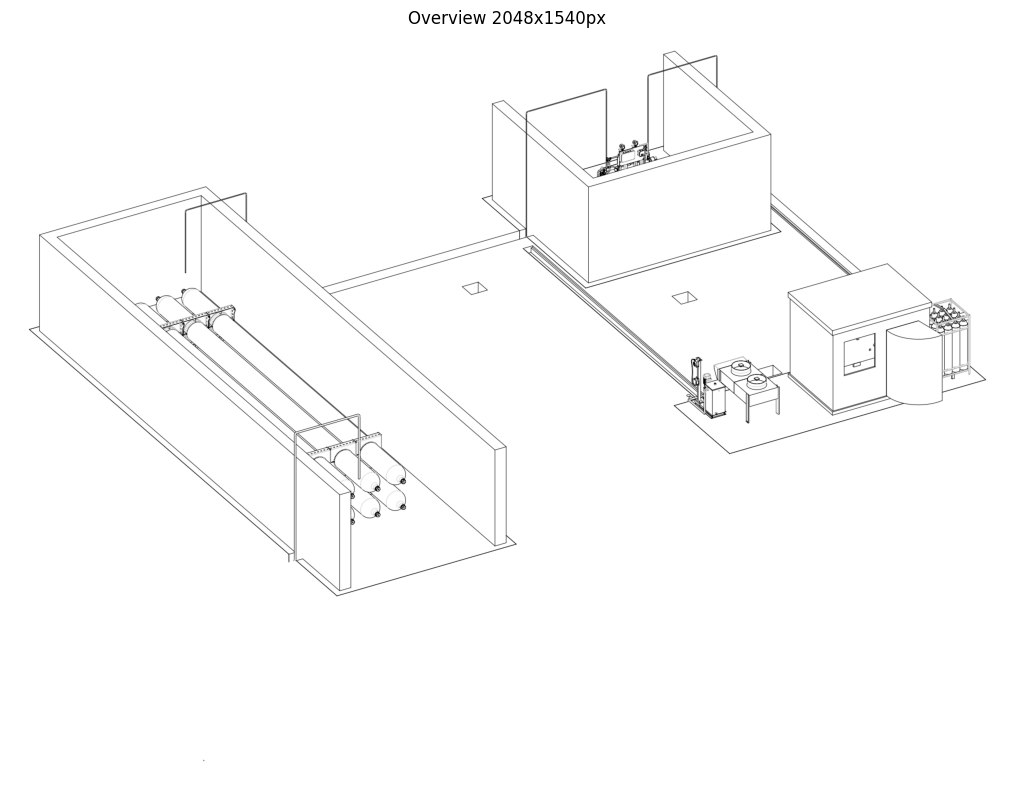

In [ ]:
print('Loading DXF ...')
DOC = ezdxf.readfile(DXF_PATH)
print(f'  {len(list(DOC.modelspace()))} top-level entities')

GX0,GY0,GX1,GY1 = get_dxf_bounds(DOC)
GW,GH = GX1-GX0,GY1-GY0
print(f'  Extents: ({GX0:.1f},{GY0:.1f}) -> ({GX1:.1f},{GY1:.1f})')

OV_PNG = os.path.join(OUTPUT_DIR,'overview.png')
print(f'Rendering overview at {OVERVIEW_PX}px ...')
overview = render_region(DOC,GX0,GY0,GX1,GY1,OVERVIEW_PX,OV_PNG)
OV_H,OV_W = overview.shape[:2]
print(f'  Overview: {OV_W}x{OV_H}px')

fig,ax=plt.subplots(figsize=(14,8))
ax.imshow(overview); ax.axis('off')
ax.set_title(f'Overview {OV_W}x{OV_H}px',fontsize=12)
plt.tight_layout(); plt.show()

## ③ Density Map → Object Candidate Regions

Building density map ...
  Raw region candidates: 2


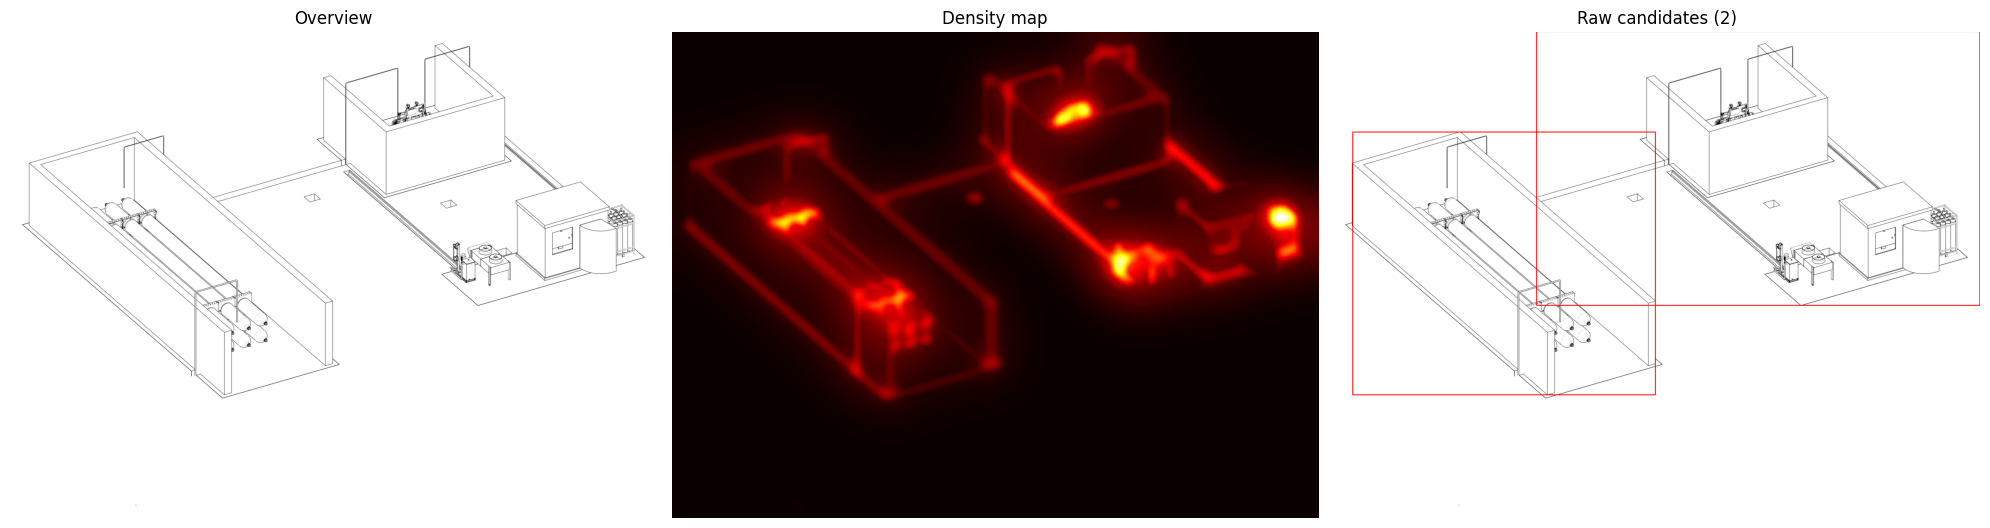

In [ ]:
def build_density_map(img_rgb, open_kernel_px, sigmas, threshold):
    """
    Convert a CAD image to object candidate regions.

    1. Grayscale + invert  →  ink = bright
    2. Morphological opening  →  kill thin connectors/pipes
    3. Multi-scale Gaussian blur  →  density field per scale
    4. Max across scales  →  combines small + large objects
    5. Threshold + watershed  →  separate touching objects

    Returns:
        density    : HxW float32 [0,1]
        labels     : HxW int32  (watershed labels, 0=bg)
        bboxes     : list of (x,y,w,h) in image pixels
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    # Invert: ink becomes bright (255), background becomes 0
    inv  = cv2.bitwise_not(gray)
    # Binarise
    _,bw = cv2.threshold(inv, 20, 255, cv2.THRESH_BINARY)

    # ── Morphological opening: kill thin lines ─────────────────────────
    k    = max(1, open_kernel_px)
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k))
    opened = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kern, iterations=2)

    # ── Multi-scale density ────────────────────────────────────────────
    density = np.zeros(opened.shape, dtype=np.float32)
    norm    = opened.astype(np.float32) / 255.0
    for sigma in sigmas:
        blurred = cv2.GaussianBlur(norm, (0,0), sigma)
        density = np.maximum(density, blurred)
    # Normalise to [0,1]
    if density.max() > 0:
        density /= density.max()

    # ── Threshold ─────────────────────────────────────────────────────
    mask = (density > threshold).astype(np.uint8) * 255

    # ── Distance transform + watershed to split touching regions ──────
    dist  = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _,sure_fg = cv2.threshold(dist, 0.3*dist.max(), 255, 0)
    sure_fg   = sure_fg.astype(np.uint8)
    sure_bg   = cv2.dilate(mask, kern, iterations=3)
    unknown   = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers    = markers + 1
    markers[unknown == 255] = 0

    img_color = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    markers   = cv2.watershed(img_color, markers)

    # ── Extract bounding boxes per label ──────────────────────────────
    bboxes = []
    for label in range(2, markers.max()+1):  # 1=bg, -1=boundary
        region = (markers == label).astype(np.uint8)
        x,y,w,h = cv2.boundingRect(region)
        if w > 0 and h > 0:
            bboxes.append((x,y,w,h))

    return density, markers, bboxes


print('Building density map ...')
density, markers, raw_bboxes = build_density_map(
    overview, OPEN_KERNEL_PX, DENSITY_SIGMAS, DENSITY_THRESHOLD)
print(f'  Raw region candidates: {len(raw_bboxes)}')

# Visualise density map
fig,axes=plt.subplots(1,3,figsize=(20,6))
axes[0].imshow(overview); axes[0].set_title('Overview'); axes[0].axis('off')
axes[1].imshow(density,cmap='hot'); axes[1].set_title('Density map'); axes[1].axis('off')

# Draw raw bboxes
vis=overview.copy()
for x,y,w,h in raw_bboxes:
    cv2.rectangle(vis,(x,y),(x+w,y+h),(255,0,0),2)
axes[2].imshow(vis); axes[2].set_title(f'Raw candidates ({len(raw_bboxes)})'); axes[2].axis('off')
plt.tight_layout(); plt.show()

## ④ Area Filter → Classify Regions

Normal (→ SAM)        : 2
Large  (→ orchestrator): 0
Noise  (discarded)    : 0


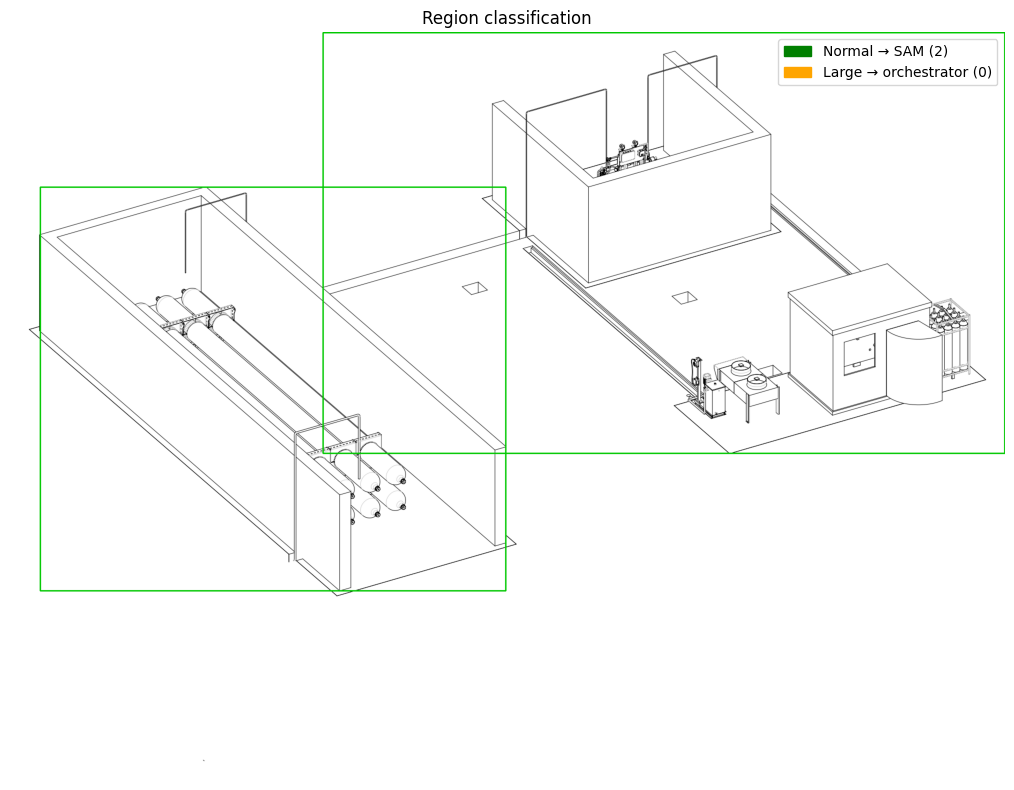

In [ ]:
overview_area = OV_W * OV_H
min_area = MIN_REGION_FRACTION * overview_area
max_area = MAX_REGION_FRACTION * overview_area

normal_boxes = []   # will go through SAM
large_boxes  = []   # save as-is for orchestrator
noise_boxes  = []   # discard

for x,y,w,h in raw_bboxes:
    area = w * h
    frac = area / overview_area
    if area < min_area:
        noise_boxes.append((x,y,w,h))
    elif area > max_area:
        large_boxes.append((x,y,w,h))
    else:
        normal_boxes.append((x,y,w,h))

print(f'Normal (→ SAM)        : {len(normal_boxes)}')
print(f'Large  (→ orchestrator): {len(large_boxes)}')
print(f'Noise  (discarded)    : {len(noise_boxes)}')

# Visualise classification
vis2 = overview.copy()
for x,y,w,h in normal_boxes:  cv2.rectangle(vis2,(x,y),(x+w,y+h),(0,200,0),2)    # green
for x,y,w,h in large_boxes:   cv2.rectangle(vis2,(x,y),(x+w,y+h),(255,165,0),2)  # orange

fig,ax=plt.subplots(figsize=(14,8))
ax.imshow(vis2); ax.axis('off')
patches=[
    mpatches.Patch(color='green',  label=f'Normal → SAM ({len(normal_boxes)})'),
    mpatches.Patch(color='orange', label=f'Large → orchestrator ({len(large_boxes)})'),
]
ax.legend(handles=patches,loc='upper right',fontsize=10)
ax.set_title('Region classification')
plt.tight_layout(); plt.show()

## ⑤ Load SAM (Predictor mode — box prompts)

In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam.to(device=DEVICE)
# SamPredictor uses BOX PROMPTS — much more targeted than automatic point grid
predictor = SamPredictor(sam)
print('SAM predictor loaded (box prompt mode)')

Device: cuda
SAM predictor loaded (box prompt mode)


## ⑥ SAM Box Prompts → Masks → Hi-Res Tiles

In [ ]:
def px_box_to_units(x,y,w,h, img_w,img_h, ux0,uy0,ux1,uy1, pad_frac=0.0):
    """Convert image pixel bbox to drawing unit bbox, with optional padding."""
    pad_x = w * pad_frac
    pad_y = h * pad_frac
    nx0 = max(0, (x-pad_x)/img_w)
    nx1 = min(1, (x+w+pad_x)/img_w)
    ny0 = max(0, (y-pad_y)/img_h)
    ny1 = min(1, (y+h+pad_y)/img_h)
    u0  = ux0 + nx0*(ux1-ux0)
    u1  = ux0 + nx1*(ux1-ux0)
    v0  = uy1 - ny1*(uy1-uy0)   # flip Y
    v1  = uy1 - ny0*(uy1-uy0)
    return u0,v0,u1,v1


def run_sam_box(sam_img, box_px):
    """
    Run SAM with a single box prompt.
    Returns best mask (HxW bool) or None.
    """
    predictor.set_image(sam_img)
    box = np.array(box_px, dtype=np.float32)
    masks, scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=box[None,:],
        multimask_output=True,
    )
    best = masks[np.argmax(scores)]
    return best


all_masks_meta = []
tile_idx = [0]

def process_normal_box(bx,by,bw,bh, box_idx):
    """
    1. Convert density bbox to DXF units (with padding)
    2. Render at SAM_INPUT_PX, run SAM
    3. Use SAM mask's tight bounding rect to compute a tighter DXF bbox
    4. Render hi-res tile from that tighter bbox
    """
    # Padded DXF bbox for SAM input
    ux0,uy0,ux1,uy1 = px_box_to_units(
        bx,by,bw,bh, OV_W,OV_H, GX0,GY0,GX1,GY1, BOX_PAD_FRACTION)

    sam_img = render_region(DOC,ux0,uy0,ux1,uy1,SAM_INPUT_PX,out_png=None)
    s_h,s_w = sam_img.shape[:2]

    box_sam = np.array([0,0,s_w,s_h],dtype=np.float32)
    mask = run_sam_box(sam_img, box_sam)

    del sam_img; gc.collect()

    if mask is None or mask.sum() < 100:
        print(f'  [box {box_idx}] SAM found no mask, skipping')
        return

    # Get tight bbox from SAM mask
    mx, my, mw, mh = cv2.boundingRect(mask.astype(np.uint8))

    # Convert mask bbox (in SAM image pixels) to DXF units with padding
    tx0, ty0, tx1, ty1 = px_box_to_units(
        mx, my, mw, mh, s_w, s_h, ux0, uy0, ux1, uy1, BOX_PAD_FRACTION)

    tid  = tile_idx[0]; tile_idx[0]+=1
    tpng = os.path.join(TILES_DIR,f'tile_{tid:04d}.png')
    hi   = render_region(DOC, tx0, ty0, tx1, ty1, TILE_LONG_EDGE_PX, tpng)
    print(f'  [box {box_idx}] tile_{tid:04d}: {hi.shape[1]}x{hi.shape[0]}px  '
          f'({os.path.getsize(tpng)/1e6:.1f} MB)  '
          f'mask covered {mw*mh/(s_w*s_h)*100:.0f}% of SAM input')
    del hi; gc.collect()

    all_masks_meta.append({
        'segment_id': f'seg_{tid:04d}',
        'tile_id': tid,
        'png_file': tpng,
        'mesh_file': '',
        'dxf_bbox': {'min_x': tx0, 'min_y': ty0, 'max_x': tx1, 'max_y': ty1},
        'bbox_overview_px': [bx,by,bw,bh],
        'type': 'normal',
        'neighbors': [],
    })


def process_large_box(bx,by,bw,bh, box_idx):
    ux0,uy0,ux1,uy1 = px_box_to_units(
        bx,by,bw,bh, OV_W,OV_H, GX0,GY0,GX1,GY1, 0.0)
    tid  = tile_idx[0]; tile_idx[0]+=1
    tpng = os.path.join(TILES_DIR,f'tile_{tid:04d}_large.png')
    hi   = render_region(DOC,ux0,uy0,ux1,uy1,TILE_LONG_EDGE_PX,tpng)
    print(f'  [large {box_idx}] tile_{tid:04d}: {hi.shape[1]}x{hi.shape[0]}px')
    del hi; gc.collect()
    all_masks_meta.append({
        'segment_id': f'seg_{tid:04d}',
        'tile_id': tid,
        'png_file': tpng,
        'mesh_file': '',
        'dxf_bbox': {'min_x': ux0, 'min_y': uy0, 'max_x': ux1, 'max_y': uy1},
        'bbox_overview_px': [bx,by,bw,bh],
        'type': 'large_overview',
        'neighbors': [],
    })


# ── Run ───────────────────────────────────────────────────────────────────
all_masks_meta.clear()
tile_idx[0] = 0

print(f'Processing {len(normal_boxes)} normal regions with SAM box prompts ...')
for i,(bx,by,bw,bh) in enumerate(normal_boxes):
    print(f'  [{i+1}/{len(normal_boxes)}]  area={bw*bh:,}px  '
          f'({bw*bh/overview_area*100:.1f}% of overview)')
    process_normal_box(bx,by,bw,bh,i)

print(f'\nProcessing {len(large_boxes)} large regions (no SAM) ...')
for i,(bx,by,bw,bh) in enumerate(large_boxes):
    process_large_box(bx,by,bw,bh,i)

print(f'\nDone. Total tiles saved: {tile_idx[0]}')

## ⑦ Save Metadata + Overlay

Adjacency computed (margin=269.1 units)
  2/2 segments have ≥1 neighbor
Metadata: ./segments_meta.json


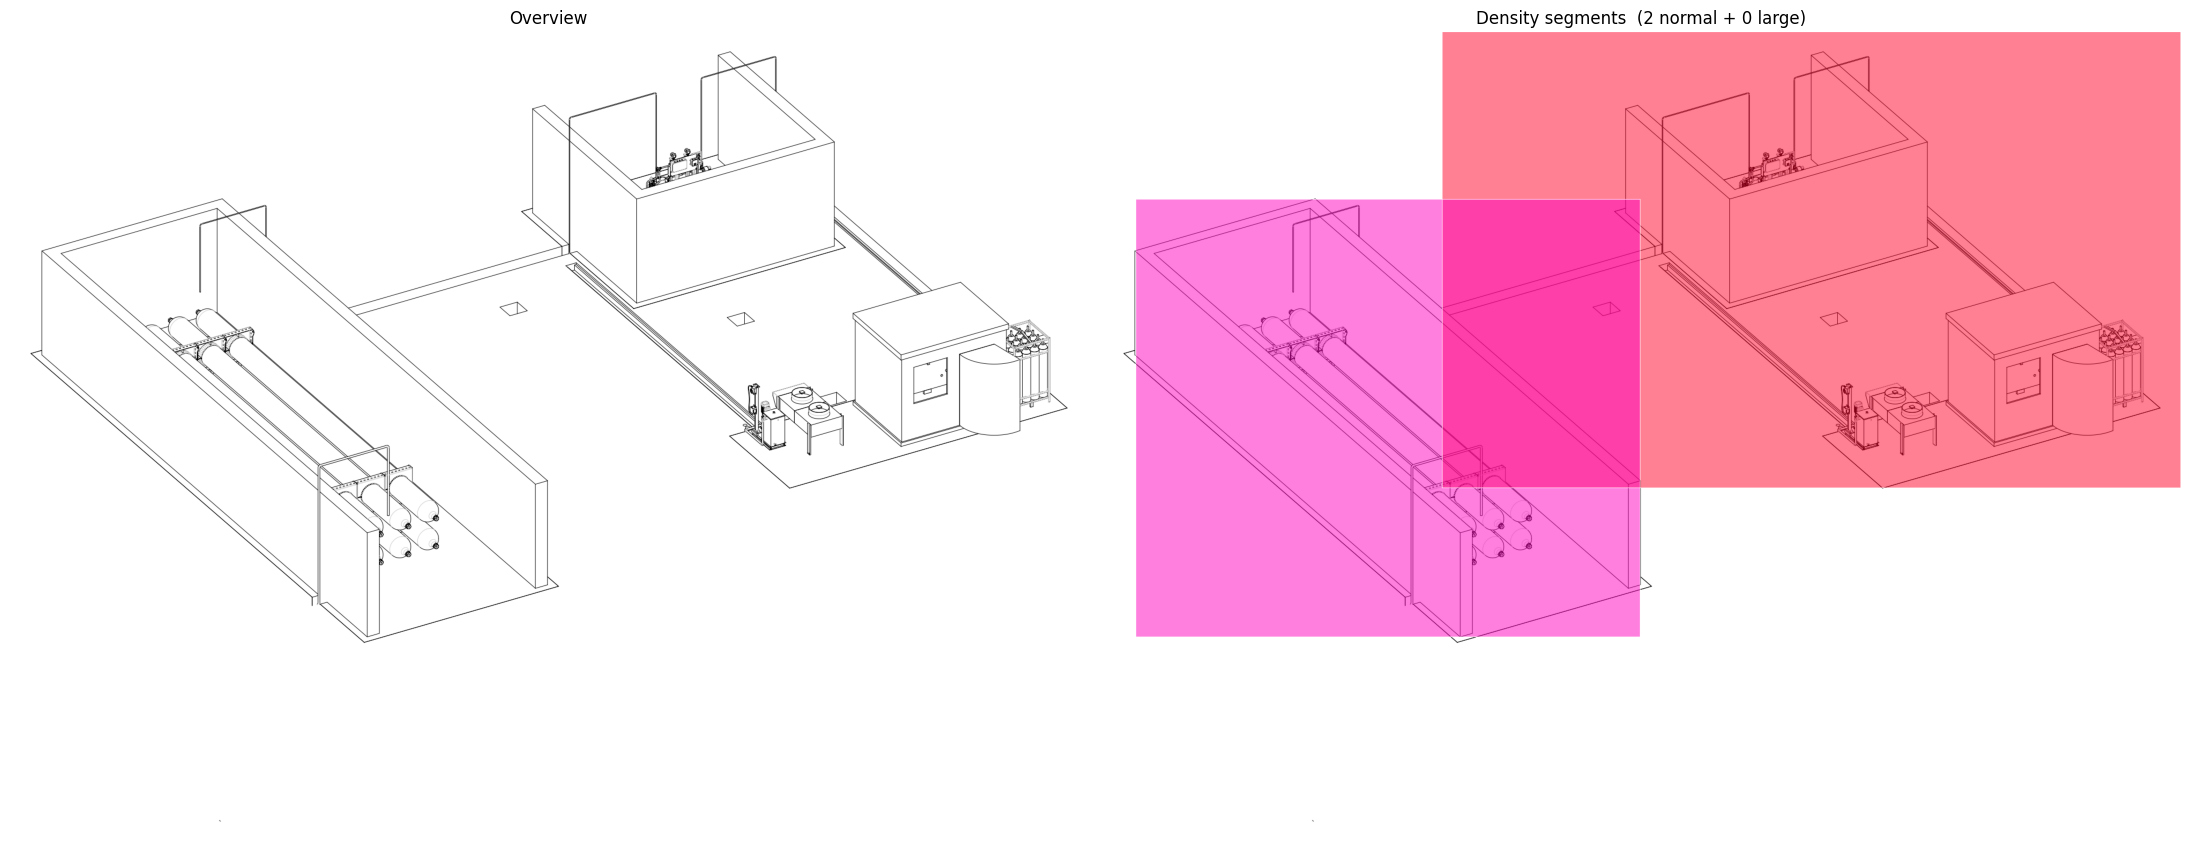

Overlay: ./density_overlay.png


In [ ]:
# ── Compute neighbor adjacency ────────────────────────────────────────────
def boxes_overlap_or_touch(b1, b2, margin=0.0):
    """Check if two dxf_bbox dicts overlap or are within margin distance."""
    return not (b1['max_x'] + margin < b2['min_x'] or
                b2['max_x'] + margin < b1['min_x'] or
                b1['max_y'] + margin < b2['min_y'] or
                b2['max_y'] + margin < b1['min_y'])

# Adjacency margin: segments within this DXF-unit distance are neighbors
ADJACENCY_MARGIN = max(GW, GH) * 0.01  # 1% of drawing extent

for i, seg_i in enumerate(all_masks_meta):
    neighbors = []
    for j, seg_j in enumerate(all_masks_meta):
        if i == j:
            continue
        if boxes_overlap_or_touch(seg_i['dxf_bbox'], seg_j['dxf_bbox'], ADJACENCY_MARGIN):
            neighbors.append(seg_j['segment_id'])
    seg_i['neighbors'] = neighbors

print(f'Adjacency computed (margin={ADJACENCY_MARGIN:.1f} units)')
n_with_neighbors = sum(1 for s in all_masks_meta if s['neighbors'])
print(f'  {n_with_neighbors}/{len(all_masks_meta)} segments have ≥1 neighbor')

# ── Save metadata (Phase 4 compatible: segments_meta.json) ────────────────
META = os.path.join(OUTPUT_DIR, 'segments_meta.json')
with open(META, 'w') as f:
    json.dump(all_masks_meta, f, indent=2)
print(f'Metadata: {META}')

# ── Colour overlay on overview ────────────────────────────────────────────
cmap   = plt.get_cmap('gist_rainbow')
canvas = overview.copy().astype(np.float32) / 255.0
n_norm = len(normal_boxes)

for i, (bx, by, bw, bh) in enumerate(normal_boxes):
    c = np.array(cmap(i / max(n_norm - 1, 1) if n_norm > 0 else 0))[:3]
    canvas[by:by+bh, bx:bx+bw] = canvas[by:by+bh, bx:bx+bw] * 0.5 + c * 0.5

overlay = (np.clip(canvas, 0, 1) * 255).astype(np.uint8)
for bx, by, bw, bh in normal_boxes:
    cv2.rectangle(overlay, (bx, by), (bx+bw, by+bh), (255, 255, 255), 1)
for bx, by, bw, bh in large_boxes:
    cv2.rectangle(overlay, (bx, by), (bx+bw, by+bh), (255, 165, 0), 2)

OVERLAY_PNG = os.path.join(OUTPUT_DIR, 'density_overlay.png')
Image.fromarray(overlay).save(OVERLAY_PNG)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
axes[0].imshow(overview); axes[0].axis('off'); axes[0].set_title('Overview')
axes[1].imshow(overlay);  axes[1].axis('off')
axes[1].set_title(f'Density segments  ({n_norm} normal + {len(large_boxes)} large)')
plt.tight_layout()
COMPARE = os.path.join(OUTPUT_DIR, 'density_comparison.png')
fig.savefig(COMPARE, dpi=120, bbox_inches='tight')
plt.show()
print(f'Overlay: {OVERLAY_PNG}')

In [ ]:
# Summary
print('='*60)
print('  Density SAM Pipeline — Summary')
print('='*60)
print(f'  DXF           : {DXF_PATH}')
print(f'  Overview      : {OV_W}x{OV_H}px')
print(f'  Tile res      : {TILE_LONG_EDGE_PX}px long-edge')
print(f'  Normal regions: {len(normal_boxes)}  (SAM box prompted)')
print(f'  Large regions : {len(large_boxes)}   (saved for orchestrator)')
print(f'  Noise dropped : {len(noise_boxes)}')
print(f'  Total tiles   : {tile_idx[0]}')
print(f'  Adjacency     : {n_with_neighbors} segments have neighbors')
print()
print('  Output format : segments_meta.json (Phase 4 compatible)')
print('  Fields per seg: segment_id, png_file, mesh_file, dxf_bbox, neighbors')
print()
print('  Outputs:')
OV_PNG = os.path.join(OUTPUT_DIR, 'overview.png')
for p in [OV_PNG, OVERLAY_PNG, COMPARE, META]:
    if os.path.exists(p):
        print(f'    {p}  ({os.path.getsize(p)/1e6:.1f} MB)')
print(f'    {TILES_DIR}/  ({tile_idx[0]} tiles)')
print('='*60)

  Density SAM Pipeline — Summary
  DXF           : HY2M - Leap mini.dwg (1) (2).dxf
  Overview      : 2048x1540px
  Tile res      : 8192px long-edge
  Normal regions: 2  (SAM box prompted)
  Large regions : 0   (saved for orchestrator)
  Noise dropped : 0
  Total tiles   : 2
  Adjacency     : 2 segments have neighbors

  Output format : segments_meta.json (Phase 4 compatible)
  Fields per seg: segment_id, png_file, mesh_file, dxf_bbox, neighbors

  Outputs:
    ./overview.png  (0.3 MB)
    ./density_overlay.png  (0.3 MB)
    ./density_comparison.png  (0.4 MB)
    ./segments_meta.json  (0.0 MB)
    ./density_tiles/  (2 tiles)


In [ ]:
# ── Download results (Colab only) ─────────────────────────────────────────
if IN_COLAB:
    import shutil, zipfile
    from google.colab import files

    zip_name = 'density_sam_results.zip'
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
        # Add metadata
        if os.path.exists(META):
            zf.write(META, os.path.basename(META))
        # Add overlay images
        for img in [OVERLAY_PNG, COMPARE]:
            if os.path.exists(img):
                zf.write(img, os.path.basename(img))
        # Add tiles
        if os.path.isdir(TILES_DIR):
            for fname in os.listdir(TILES_DIR):
                fpath = os.path.join(TILES_DIR, fname)
                zf.write(fpath, os.path.join('density_tiles', fname))

    sz = os.path.getsize(zip_name) / 1e6
    print(f'Downloading {zip_name} ({sz:.1f} MB) ...')
    files.download(zip_name)
else:
    print('Not in Colab — results saved locally.')
    print(f'  Metadata: {META}')
    print(f'  Tiles:    {TILES_DIR}/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>